(9022, 14)
seq                   0
Property_ID           0
Area_m2               0
Bedrooms              0
Bathrooms             0
Floor                 0
Property_Age          0
Distance_Center_km    0
Property_Type         0
Furnished             0
Parking               0
Location              0
Price_EGP             0
High_Demand           0
dtype: int64
(9022, 14)
   seq Property_ID  Area_m2  Bedrooms  Bathrooms  Floor  Property_Age  \
0    1      P05842    206.9         2          1     15          28.0   
1    2      P02806    161.6         2          1      8           4.0   
2    3      P07843    257.7         3          3      2           1.0   
3    4      P07840    123.6         1          2      6           5.0   
4    5      P03998    216.9         5          4      7          11.0   

   Distance_Center_km  Furnished  Parking  Price_EGP  High_Demand  \
0                5.95          1        1    4204075            1   
1                2.80          1        0    2288026

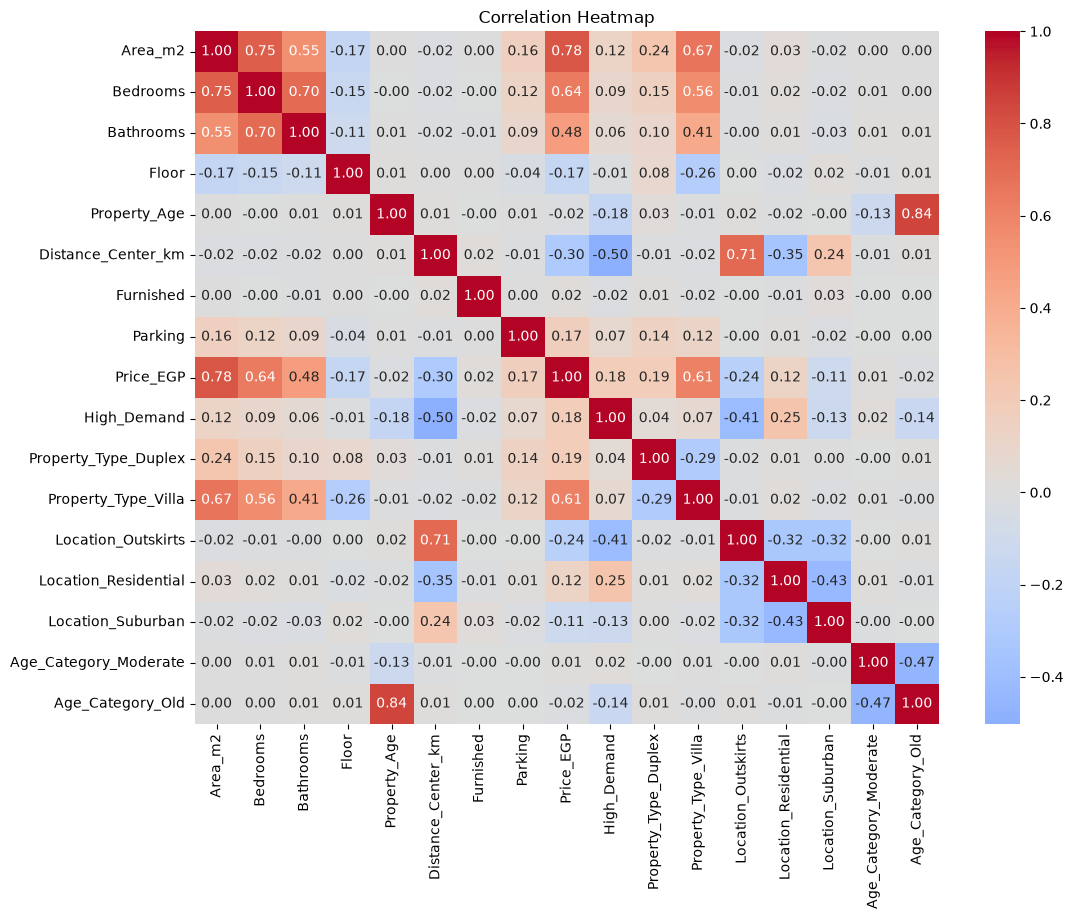

['Area_m2', 'Bedrooms', 'Bathrooms', 'Floor', 'Distance_Center_km', 'Parking', 'Property_Type_Duplex', 'Property_Type_Villa', 'Location_Outskirts', 'Location_Residential', 'Location_Suburban']
Regression -> Train size: (7217, 14)  Test size: (1805, 14)
Classification -> Train size: (7217, 15)  Test size: (1805, 15)
Linear Regression model trained successfully!
Predictions completed successfully!
MAE : 698156.53
MSE : 1000475709673.97
RMSE: 1000237.83
R²  : 0.711
Predictions completed successfully!
Accuracy : 0.756
Precision: 0.766
Recall   : 0.849
F1 Score : 0.806

Confusion Matrix:
[[450 279]
 [162 914]]

Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.62      0.67       729
           1       0.77      0.85      0.81      1076

    accuracy                           0.76      1805
   macro avg       0.75      0.73      0.74      1805
weighted avg       0.75      0.76      0.75      1805



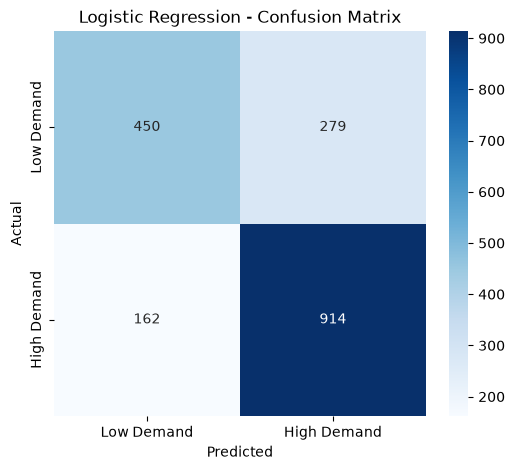

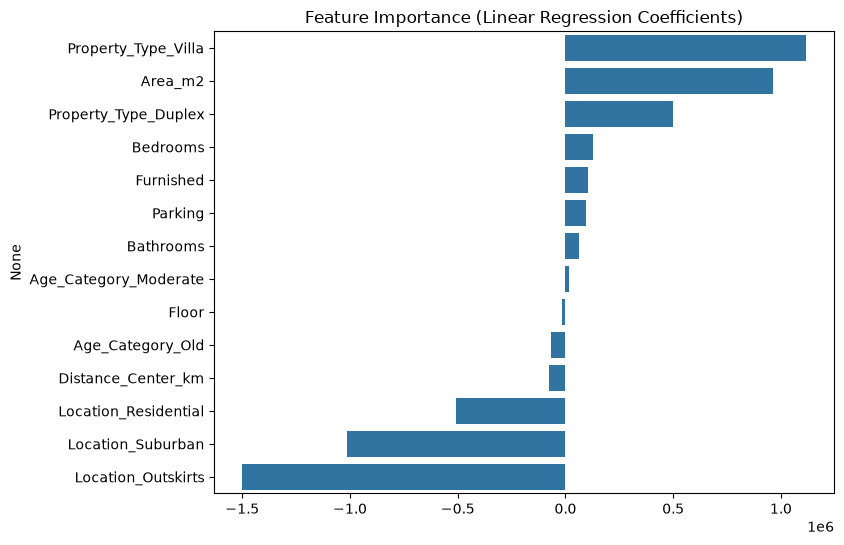

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)


df = pd.read_csv('real_estate_predictive_analytics1.csv')
print(df.shape)
df.head()


area_median = df['Area_m2'].median()
age_median = df['Property_Age'].median()

df['Area_m2'] = df['Area_m2'].fillna(area_median)
df['Property_Age'] = df['Property_Age'].fillna(age_median)

print(df.isnull().sum())

df = df.drop_duplicates()
print(df.shape)


bins = [-1, 5, 15, 100]
labels = ['New', 'Moderate', 'Old']
df['Age_Category'] = pd.cut(df['Property_Age'], bins=bins, labels=labels)

binary_map = {'Yes': 1, 'No': 0}
df['Furnished'] = df['Furnished'].map(binary_map)
df['Parking'] = df['Parking'].map(binary_map)
df['High_Demand'] = df['High_Demand'].map(binary_map)

df = pd.get_dummies(df, columns=['Property_Type', 'Location', 'Age_Category'], drop_first=True)

print(df.head())

df = df.drop(columns=['seq', 'Property_ID'], errors='ignore')


numeric_features = ['Area_m2', 'Bedrooms', 'Bathrooms', 'Floor',
                     'Property_Age', 'Distance_Center_km']

scaler = StandardScaler()
df[numeric_features] = scaler.fit_transform(df[numeric_features])
print(df[numeric_features].describe())


corr_matrix = df.corr(numeric_only=True)
print(corr_matrix['Price_EGP'].sort_values(ascending=False))

plt.figure(figsize=(12, 9))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()

#
correlation_threshold = 0.10
target_correlation = corr_matrix['Price_EGP'].drop(['Price_EGP', 'High_Demand'])
selected_features = target_correlation[abs(target_correlation) > correlation_threshold].index.tolist()
print(selected_features)


extra_cols = [c for c in df.columns if c.startswith('Property_Type_')
              or c.startswith('Location_') or c.startswith('Age_Category_')]

reg_features = list(dict.fromkeys(selected_features + ['Furnished', 'Parking'] + extra_cols))

X_reg = df[reg_features]
y_reg = df['Price_EGP']

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

print("Regression -> Train size:", X_train_reg.shape, " Test size:", X_test_reg.shape)


clf_features = reg_features + ['Price_EGP']

X_clf = df[clf_features]
y_clf = df['High_Demand']

X_clf = X_clf.loc[:, ~X_clf.columns.duplicated()]

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

print("Classification -> Train size:", X_train_clf.shape, " Test size:", X_test_clf.shape)


lin_reg = LinearRegression()
lin_reg.fit(X_train_reg, y_train_reg)
print("Linear Regression model trained successfully!")

y_pred_reg = lin_reg.predict(X_test_reg)
print("Predictions completed successfully!")

mae = mean_absolute_error(y_test_reg, y_pred_reg)
mse = mean_squared_error(y_test_reg, y_pred_reg)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_reg, y_pred_reg)

print("MAE :", round(mae, 2))
print("MSE :", round(mse, 2))
print("RMSE:", round(rmse, 2))
print("R²  :", round(r2, 3))


log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_clf, y_train_clf)

y_pred_clf = log_reg.predict(X_test_clf)
print("Predictions completed successfully!")

accuracy = accuracy_score(y_test_clf, y_pred_clf)
precision = precision_score(y_test_clf, y_pred_clf)
recall = recall_score(y_test_clf, y_pred_clf)
f1 = f1_score(y_test_clf, y_pred_clf)

print("Accuracy :", round(accuracy, 3))
print("Precision:", round(precision, 3))
print("Recall   :", round(recall, 3))
print("F1 Score :", round(f1, 3))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_clf, y_pred_clf))

print("\nClassification Report:")
print(classification_report(y_test_clf, y_pred_clf))


cm = confusion_matrix(y_test_clf, y_pred_clf)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Low Demand', 'High Demand'],
    yticklabels=['Low Demand', 'High Demand']
)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Logistic Regression - Confusion Matrix')
plt.show()


importances = pd.Series(lin_reg.coef_, index=reg_features).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(x=importances.values, y=importances.index)
plt.title('Feature Importance (Linear Regression Coefficients)')
plt.show()